In [1]:
import numpy as np
from akf_gnss_ins.drone_expriment.mmodel import fake_nn_prediction_torch
from akf_gnss_ins.drone_expriment.data_io import ecef
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False



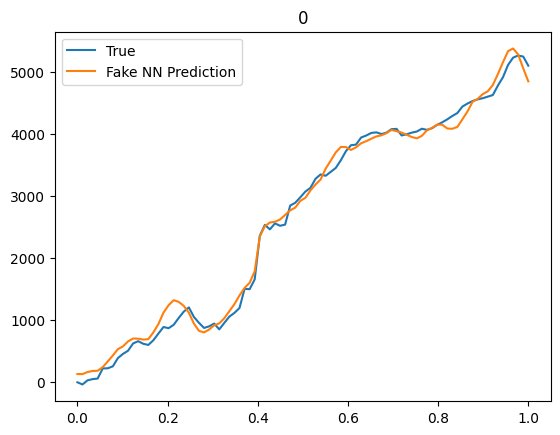

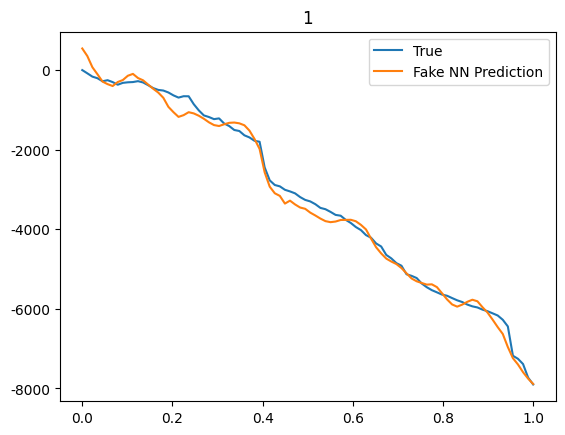

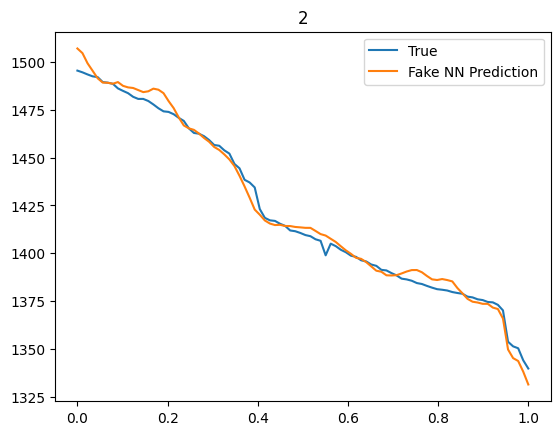

In [17]:
res = []
for i in range(3):
    y = ecef[:, i]

    # ✅ 标准化
    y_mean = y.mean()
    y_std = y.std()
    y_norm = (y - y_mean) / y_std

    x = np.arange(len(y))
    x = x / x.max()  # 也顺便归一化

    y_pred_norm = fake_nn_prediction_torch(x, y_norm, epochs=10000, low_freq_avg=0.3, high_freq_avg=0.03)

    # ✅ 还原
    y_pred = y_pred_norm * y_std + y_mean

    plt.plot(x, y, label="True")
    plt.plot(x, y_pred, label="Fake NN Prediction")
    plt.title(i)
    plt.legend()
    plt.show()
    res.append(y_pred)

In [18]:
from datetime import datetime
now = datetime.now()
time_str = now.strftime("%Y%m%d-%H%M%S")

data = np.column_stack(res)  # shape: (90, 3)

file_name = f'pred_{time_str}_akf.csv'
np.savetxt(file_name, data, delimiter=",")

In [20]:
print(ecef)

[[    0.             0.          1495.5       ]
 [  -35.36701485   -81.16888564  1494.59998   ]
 [   31.43195121  -164.23397878  1493.5       ]
 [   50.75104153  -204.55708122  1492.5       ]
 [   60.19638157  -280.6282289   1492.09998   ]
 [  222.91891568  -253.94908295  1489.5       ]
 [  225.4836832   -301.57143789  1489.19995   ]
 [  256.97859944  -367.31131691  1488.59998   ]
 [  389.99300103  -320.90026666  1486.19995   ]
 [  457.49719349  -306.82173376  1484.90002   ]
 [  508.49039771  -300.5480837   1483.69995   ]
 [  625.91863226  -277.9667594   1481.80005   ]
 [  661.75664761  -310.51119243  1480.69995   ]
 [  620.28342827  -378.92853847  1480.69995   ]
 [  601.49228615  -452.42324842  1479.60315   ]
 [  677.41338692  -498.1931032   1477.80005   ]
 [  786.08771761  -513.71059594  1475.80005   ]
 [  890.47138174  -562.54669138  1474.19995   ]
 [  871.36328465  -635.37810052  1473.90002   ]
 [  925.08857836  -691.18004572  1472.69995   ]
 [ 1036.75814316  -656.60142137  1470.80